# Model Explainability using SHAP

In this notebook, we explain the predictions made by the best-performing model (Random Forest) using SHAP (SHapley Additive exPlanations).

The visualizations include:

- Feature Importance
- SHAP Beeswarm Plot
- SHAP Waterfall Plot

In [1]:
# Uncomment if SHAP is not installed
# !pip install shap

In [4]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
rf_model = joblib.load(
    r"C:\Users\athar\OneDrive\Desktop\credit\models\random_forest.pkl"
)

In [6]:
X_test = pd.read_csv(
    r"C:\Users\athar\OneDrive\Desktop\credit\data\processed\X_test.csv"
)

## Create SHAP Explainer

In [7]:
explainer = shap.TreeExplainer(rf_model)

In [8]:
shap_values = explainer.shap_values(X_test.iloc[:500])

## SHAP Feature Importance

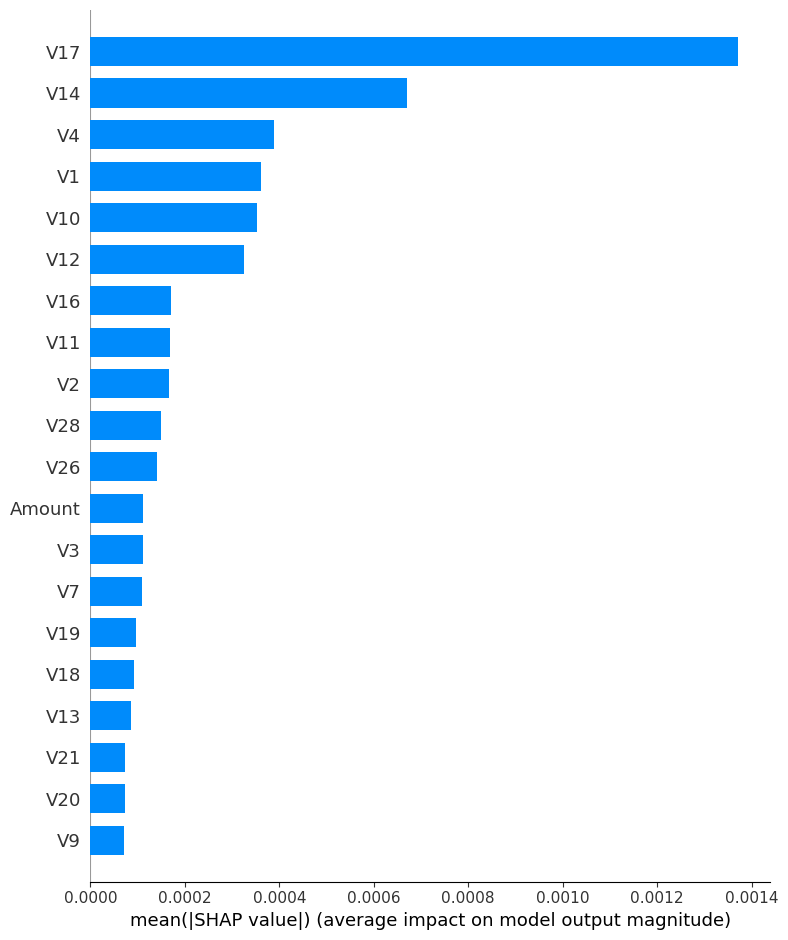

In [13]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],      # Fraud class
    X_test.iloc[:500],
    plot_type="bar",
    show=False
)

plt.savefig(
    r"C:\Users\athar\OneDrive\Desktop\credit\images\shap_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

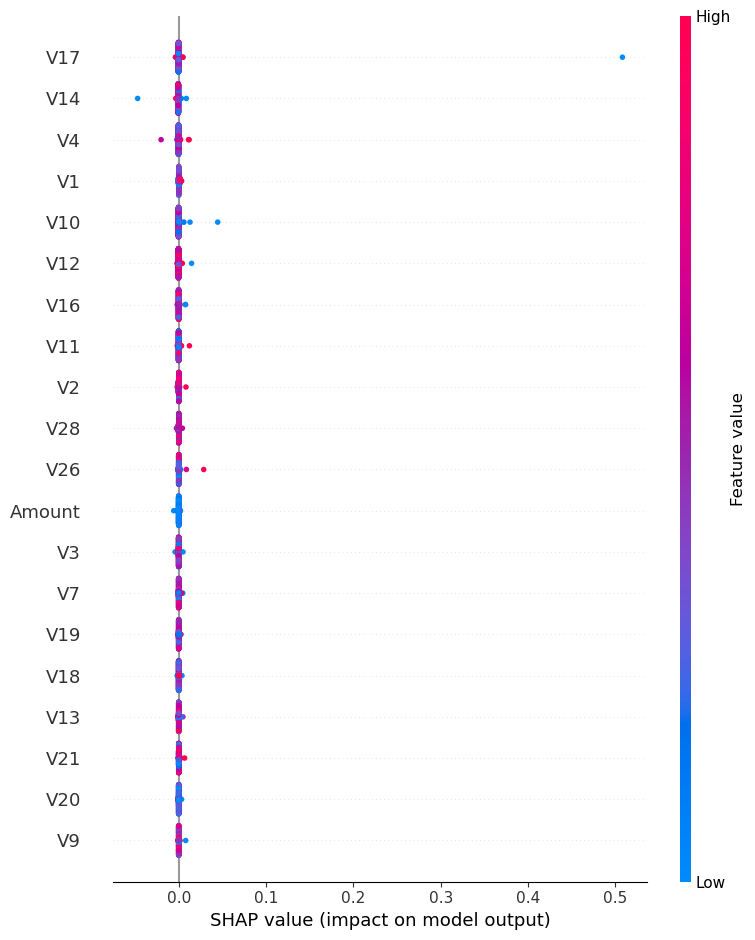

In [14]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values[:, :, 1],      # Fraud class
    X_test.iloc[:500],
    show=False
)

plt.savefig(
    r"C:\Users\athar\OneDrive\Desktop\credit\images\shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

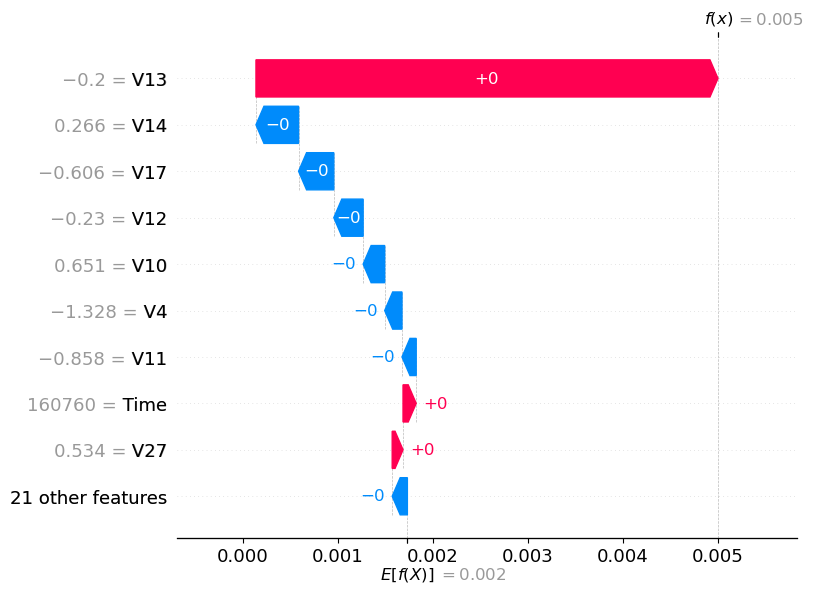

In [15]:
explanation = shap.Explanation(
    values=shap_values[0, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[0].values,
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation, show=False)

plt.savefig(
    r"C:\Users\athar\OneDrive\Desktop\credit\images\shap_waterfall_fraud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

SHAP provides insights into how the Random Forest model makes predictions.

- The feature importance plot highlights the most influential features.
- The beeswarm plot shows how feature values affect model predictions across multiple samples.
- The waterfall plot explains an individual prediction by showing how each feature contributes to the final output.

These visualizations improve the transparency and interpretability of the fraud detection model.